In [1]:
print("Hello An")

Hello An


# 2.0 — Chia tập dữ liệu & Tạo Sliding Window

**Input:** `data/processed_storms.parquet` (từ Notebook 1.0)

**Pipeline:**
1. Chia train / val / test **theo thời gian** (không random → tránh leakage)
2. Chuẩn hóa features (StandardScaler fit chỉ trên train)
3. Tạo sliding window → tensor `[N, W, F]` cho LSTM/Transformer
4. Kiểm tra chất lượng: phân bố, class balance, target stats
5. Vẽ bản đồ địa lý với quỹ đạo từng split
6. Lưu `data/splits/` cho Notebook 3.0

**Target:** Δlat, Δlon (đường đi) + wind_kt, pressure_mb, intensity_class (cường độ)  
**Horizons:** 6h, 12h, 24h, 48h, 72h


## 0. Imports & Cấu hình

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import seaborn as sns
import json, pickle, warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# ── GPU check ──────────────────────────────────────────────────────────────────
try:
    import torch
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    if DEVICE == 'cuda':
        print(f'GPU : {torch.cuda.get_device_name(0)}')
        print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    else:
        print('CPU mode (cài PyTorch + CUDA để train nhanh hơn)')
except ImportError:
    DEVICE = 'cpu'; print('PyTorch chưa cài')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('data')
SPLIT_DIR = DATA_DIR / 'splits'
PLOT_DIR  = DATA_DIR / 'plots'
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FILE_IN   = DATA_DIR / 'processed_storms.parquet'
FILE_META = DATA_DIR / 'metadata.json'

# ── Hyperparameters ────────────────────────────────────────────────────────────
WINDOW_SIZE    = 8        # 8 × 6h = 48h lịch sử
HORIZONS_H     = [6, 12, 24, 48, 72]
STEP_HOURS     = 6
HORIZONS_STEPS = [h // STEP_HOURS for h in HORIZONS_H]   # [1,2,4,8,12]

TRAIN_YEARS = (1996, 2018)
VAL_YEARS   = (2019, 2021)
TEST_YEARS  = (2022, 2023)

INTENSITY_COLORS = {
    'TD':'#90caf9','TS':'#42a5f5','C1':'#ffee58',
    'C2':'#ffa726','C3':'#ef5350','C4':'#ab47bc','C5':'#4a148c'
}
SAFFIR_LABEL = {0:'TD',1:'TS',2:'C1',3:'C2',4:'C3',5:'C4',6:'C5'}

print(f'Window   : {WINDOW_SIZE} bước = {WINDOW_SIZE*STEP_HOURS}h')
print(f'Horizons : {HORIZONS_H}h → steps {HORIZONS_STEPS}')
print(f'Train    : {TRAIN_YEARS[0]}–{TRAIN_YEARS[1]}')
print(f'Val      : {VAL_YEARS[0]}–{VAL_YEARS[1]}')
print(f'Test     : {TEST_YEARS[0]}–{TEST_YEARS[1]}')


GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Window   : 8 bước = 48h
Horizons : [6, 12, 24, 48, 72]h → steps [1, 2, 4, 8, 12]
Train    : 1996–2018
Val      : 2019–2021
Test     : 2022–2023


---
## 1. Định nghĩa hàm vẽ bản đồ địa lý Atlantic
> Không cần cartopy — dùng polygon bờ biển tự nhúng, hoạt động 100% offline.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Polygon bờ biển Atlantic basin (simplified từ Natural Earth 110m)
# Encode trực tiếp — không cần download hay cartopy
# ═══════════════════════════════════════════════════════════════════════════════

_LAND_POLYS = {
    # ── Bắc Mỹ & Canada ────────────────────────────────────────────────────────
    'north_america': [
        (-67.0,47.0),(-67.5,45.0),(-70.2,43.5),(-71.0,42.4),(-73.8,40.6),
        (-74.0,40.5),(-75.4,38.8),(-76.3,37.0),(-76.0,35.9),(-77.0,34.7),
        (-78.5,33.8),(-79.8,32.7),(-81.2,31.9),(-81.4,30.9),(-81.8,30.0),
        (-82.6,29.5),(-84.0,29.7),(-85.5,30.0),(-87.5,30.3),(-89.0,29.0),
        (-90.0,29.0),(-91.0,29.0),(-93.0,29.8),(-94.8,29.0),(-97.4,25.8),
        (-105.0,20.5),(-109.5,23.5),(-116.5,31.0),(-117.1,32.5),
        (-118.5,34.0),(-120.5,34.5),(-122.0,37.2),(-124.0,40.5),
        (-124.7,48.5),(-123.0,49.0),(-100.0,49.0),(-88.5,48.0),
        (-84.0,45.5),(-82.0,41.5),(-79.0,43.5),(-76.0,44.5),
        (-72.5,45.5),(-71.0,46.5),(-69.5,47.5),(-67.0,47.0),
    ],
    # ── Florida peninsula ─────────────────────────────────────────────────────
    'florida': [
        (-87.5,30.3),(-85.5,30.0),(-84.0,29.7),(-82.6,29.5),
        (-81.8,30.0),(-81.4,30.9),(-81.2,31.9),
        (-80.5,24.5),(-81.5,25.1),(-83.0,27.5),(-84.0,29.7),
    ],
    # ── México + América Central ───────────────────────────────────────────────
    'mexico_ca': [
        (-97.4,25.8),(-97.0,22.5),(-95.0,19.5),(-91.5,18.5),
        (-88.3,15.8),(-83.7,10.0),(-77.4,8.0),(-76.0,9.0),
        (-75.5,11.0),(-68.0,12.0),(-63.5,10.5),(-62.0,8.0),
        (-52.0,4.0),(-51.0,4.5),(-57.0,7.0),(-58.5,7.5),
        (-63.0,7.5),(-65.0,10.5),(-67.0,11.0),(-70.0,12.0),
        (-76.0,9.0),(-77.0,7.5),(-77.4,8.0),
        (-83.7,10.0),(-88.3,15.8),(-90.5,18.5),(-92.0,20.5),
        (-87.0,21.5),(-86.8,20.5),(-88.3,15.8),(-90.5,18.5),
        (-94.5,18.5),(-96.0,20.0),(-97.5,22.5),(-97.4,25.8),
    ],
    # ── Cuba ──────────────────────────────────────────────────────────────────
    'cuba': [
        (-84.5,22.0),(-82.0,23.2),(-79.5,22.5),(-75.0,20.0),
        (-74.0,20.0),(-75.0,19.8),(-77.5,20.0),(-80.0,22.0),(-84.5,22.0),
    ],
    # ── Hispaniola (Haiti + DR) ────────────────────────────────────────────────
    'hispaniola': [
        (-74.5,19.6),(-72.0,18.5),(-69.0,18.5),(-68.0,19.0),
        (-69.0,19.8),(-72.0,20.0),(-74.5,19.6),
    ],
    # ── Jamaica ───────────────────────────────────────────────────────────────
    'jamaica': [
        (-77.9,18.4),(-77.0,17.9),(-76.2,17.9),
        (-76.0,18.2),(-76.5,18.5),(-77.9,18.4),
    ],
    # ── Puerto Rico ───────────────────────────────────────────────────────────
    'puerto_rico': [
        (-67.3,18.0),(-66.0,17.9),(-65.6,18.2),(-67.3,18.4),(-67.3,18.0),
    ],
    # ── Tây Âu ────────────────────────────────────────────────────────────────
    'europe_w': [
        (-9.0,38.5),(-8.5,37.0),(-7.0,37.0),(-6.0,36.0),(-5.5,36.0),
        (-5.3,36.1),(0.5,38.5),(3.0,40.0),(3.0,42.5),(4.0,43.5),
        (7.5,43.5),(7.0,44.0),(4.0,43.5),(1.0,43.0),(-0.5,43.5),
        (-1.5,43.5),(-4.5,43.8),(-8.5,43.5),(-9.0,41.5),(-9.5,40.0),(-9.0,38.5),
    ],
    # ── Quần đảo Anh ──────────────────────────────────────────────────────────
    'british_isles': [
        (-5.5,50.0),(-4.0,50.0),(-3.0,51.0),(0.5,51.5),(1.5,51.0),
        (0.0,53.0),(-2.0,54.5),(-5.5,55.5),(-6.0,58.0),(-5.0,58.5),
        (-4.0,57.5),(-2.0,57.5),(-3.5,54.5),(-4.5,53.5),
        (-4.0,52.0),(-5.5,51.5),(-5.5,50.0),
    ],
    # ── Ireland ───────────────────────────────────────────────────────────────
    'ireland': [
        (-10.0,51.5),(-8.5,51.5),(-8.0,52.0),(-9.0,54.0),
        (-10.0,54.5),(-8.5,55.5),(-6.5,55.0),(-6.0,54.0),
        (-7.5,52.0),(-10.0,51.5),
    ],
    # ── Bờ Tây Phi ────────────────────────────────────────────────────────────
    'africa_nw': [
        (-5.5,36.0),(-5.3,36.1),(-2.0,35.0),(-5.5,35.8),
        (-8.0,35.0),(-8.5,33.5),(-9.5,33.5),(-11.0,33.0),
        (-13.0,28.0),(-15.5,24.0),(-17.0,21.0),(-17.0,15.0),
        (-16.0,13.5),(-15.5,12.0),(-14.5,11.0),(-12.0,9.5),
        (-10.5,9.0),(-8.5,7.5),(-4.5,5.5),(0.0,5.0),(2.0,5.5),
        (5.0,5.5),(8.5,4.5),(9.5,1.0),(9.0,0.0),(8.5,-1.5),
        (9.0,3.5),(5.0,5.5),(2.0,5.5),(0.0,5.0),
        (-8.5,7.5),(-14.0,10.0),(-17.0,21.0),
        (-15.5,24.0),(-11.0,33.0),(-5.5,35.8),(-5.5,36.0),
    ],
    # ── Scandinavia ───────────────────────────────────────────────────────────
    'scandinavia': [
        (-2.5,56.0),(0.0,57.5),(5.5,58.0),(8.0,58.5),(8.0,57.0),
        (8.5,55.0),(9.5,55.5),(10.5,57.5),(10.0,59.0),(11.5,60.0),
        (14.0,65.0),(16.0,68.0),(18.0,70.0),(28.0,71.0),(30.0,70.0),
        (28.5,68.5),(25.0,64.0),(24.0,60.0),(25.0,58.0),(22.0,57.0),
        (18.0,56.5),(14.0,56.0),(12.5,56.5),(10.5,57.5),
        (10.0,55.5),(8.5,55.0),(5.5,58.0),(0.0,57.5),(-2.5,56.0),
    ],
}


def draw_atlantic_basemap(
    ax,
    extent: tuple = (-110, 15, 5, 62),
    ocean_color: str = '#b8d8ed',
    land_color:  str = '#ddd5c0',
    edge_color:  str = '#999080',
    grid: bool = True,
) -> None:
    """
    Vẽ bản đồ Atlantic basin với bờ biển và đảo.
    Không cần cartopy, geopandas hay internet.

    Parameters
    ----------
    ax      : matplotlib Axes
    extent  : (lon_min, lon_max, lat_min, lat_max)
    """
    lonmin, lonmax, latmin, latmax = extent
    ax.set_xlim(lonmin, lonmax)
    ax.set_ylim(latmin, latmax)
    ax.set_facecolor(ocean_color)

    # Vẽ từng polygon lục địa / đảo
    for name, pts in _LAND_POLYS.items():
        arr = np.array(pts)
        # Chỉ vẽ polygon có điểm nào đó trong/gần viewport
        if not (np.any(arr[:,0] > lonmin - 10) and
                np.any(arr[:,0] < lonmax + 10) and
                np.any(arr[:,1] > latmin - 10) and
                np.any(arr[:,1] < latmax + 10)):
            continue
        poly = MplPolygon(
            arr, closed=True,
            facecolor=land_color, edgecolor=edge_color,
            linewidth=0.6, alpha=1.0, zorder=2,
        )
        ax.add_patch(poly)

    if grid:
        for lon in range(-120, 25, 10):
            if lonmin <= lon <= lonmax:
                ax.axvline(lon, color='white', lw=0.35, alpha=0.7, zorder=1)
        for lat in range(0, 75, 10):
            if latmin <= lat <= latmax:
                ax.axhline(lat, color='white', lw=0.35, alpha=0.7, zorder=1)

    # Tick labels
    xt = [l for l in range(-120, 25, 10) if lonmin <= l <= lonmax]
    ax.set_xticks(xt)
    ax.set_xticklabels(
        [f"{abs(l)}°{'W' if l<0 else ('E' if l>0 else '')}" for l in xt],
        fontsize=7
    )
    yt = [l for l in range(0, 75, 10) if latmin <= l <= latmax]
    ax.set_yticks(yt)
    ax.set_yticklabels([f"{l}°N" for l in yt], fontsize=7)
    ax.set_xlabel('Kinh độ', fontsize=9)
    ax.set_ylabel('Vĩ độ', fontsize=9)


print('draw_atlantic_basemap() đã định nghĩa — không cần cartopy.')


draw_atlantic_basemap() đã định nghĩa — không cần cartopy.


---
## 2. Load dữ liệu & feature list

In [4]:
df = pd.read_parquet(FILE_IN)
print(f'Dataset: {len(df):,} dòng | {df["storm_id"].nunique()} bão')
print(f'Cột    : {list(df.columns)}')
display(df.head(5))

# Đọc feature list từ metadata
if FILE_META.exists():
    meta = json.loads(FILE_META.read_text())
    INPUT_FEATURES    = meta['input_features']
    TARGET_TRACK      = meta['target_track']
    TARGET_INTENSITY  = meta['target_intensity']
    TARGET_CLASS      = meta['target_class']
    print(f'\nInput features: {len(INPUT_FEATURES)}')
else:
    # Fallback
    INPUT_FEATURES = [
        'lat','lon','delta_lat','delta_lon','speed_kmh','bearing_sin','bearing_cos',
        'delta_lat_12h','delta_lon_12h','speed_mean_24h','wind_kt','pressure_mb',
        'delta_wind_kt','delta_pres_mb','wind_trend_12h','wind_trend_24h',
        'pres_trend_12h','pres_trend_24h','is_RI',
        'month_sin','month_cos','hour_sin','hour_cos','storm_age_h','is_peak_season',
        'noaa_damage_B','noaa_deaths',
    ]
    TARGET_TRACK     = ['delta_lat','delta_lon']
    TARGET_INTENSITY = ['wind_kt','pressure_mb']
    TARGET_CLASS     = ['intensity_class']

# Chỉ giữ feature có trong df
INPUT_FEATURES = [f for f in INPUT_FEATURES if f in df.columns]
ALL_TARGETS    = TARGET_TRACK + [t for t in TARGET_INTENSITY + TARGET_CLASS if t in df.columns]
print(f'Features hợp lệ: {len(INPUT_FEATURES)}')
print(f'Targets         : {ALL_TARGETS}')


Dataset: 9,653 dòng | 388 bão
Cột    : ['storm_id', 'storm_name', 'Date', 'Time_UTC', 'status', 'Latitude', 'Longitude', 'wind_kt', 'pressure_mb', 'lat', 'lon', 'date_str', 'time_str', 'timestamp', 'year', 'month', 'day', 'hour', 'noaa_damage_B', 'noaa_deaths', 'noaa_injuries', 'noaa_n_episodes', 'intensity_class', 'intensity_label', 'lat_prev', 'lon_prev', 'delta_lat', 'delta_lon', 'dist_km', 'speed_kmh', 'bearing', 'bearing_sin', 'bearing_cos', 'wind_trend_12h', 'wind_trend_24h', 'pres_trend_12h', 'pres_trend_24h', 'delta_lat_12h', 'delta_lon_12h', 'speed_mean_24h', 'delta_wind_kt', 'delta_pres_mb', 'wind_change_24h', 'is_RI', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'storm_age_step', 'storm_age_h', 'is_peak_season']


,storm_id,storm_name,Date,Time_UTC,status,Latitude,Longitude,wind_kt,pressure_mb,lat,...,delta_pres_mb,wind_change_24h,is_RI,month_sin,month_cos,hour_sin,hour_cos,storm_age_step,storm_age_h,is_peak_season
0,AL011996,ARTHUR,19960618,0,TD,27.7N,78.3W,25.0,1010.0,27.7,...,NaN,NaN,0,1.224647e-16,-1.0,0.000000e+00,1.000000e+00,0,0,0
1,AL011996,ARTHUR,19960618,600,TD,28.6N,78.8W,25.0,1009.0,28.6,...,-1.0,NaN,0,1.224647e-16,-1.0,1.000000e+00,6.123234e-17,1,6,0
2,AL011996,ARTHUR,19960618,1200,TD,29.7N,78.8W,25.0,1008.0,29.7,...,-1.0,NaN,0,1.224647e-16,-1.0,1.224647e-16,-1.000000e+00,2,12,0
3,AL011996,ARTHUR,19960618,1800,TD,30.6N,78.7W,30.0,1008.0,30.6,...,0.0,NaN,0,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16,3,18,0
4,AL011996,ARTHUR,19960619,0,TS,31.5N,78.7W,35.0,1004.0,31.5,...,-4.0,10.0,0,1.224647e-16,-1.0,0.000000e+00,1.000000e+00,4,24,0


Features hợp lệ: 27
Targets         : ['delta_lat', 'delta_lon', 'wind_kt', 'pressure_mb', 'intensity_class']


---
## 3. Chia Train / Val / Test theo năm

In [5]:
if 'year' not in df.columns:
    df['year'] = pd.to_datetime(df['timestamp']).dt.year

df_train = df[df['year'].between(*TRAIN_YEARS)].copy()
df_val   = df[df['year'].between(*VAL_YEARS)  ].copy()
df_test  = df[df['year'].between(*TEST_YEARS) ].copy()

print('┌─────────────────────────────────────────────────────────┐')
print('│                  PHÂN BỐ DATASET SPLIT                  │')
print('├──────────┬──────────────┬──────────┬────────────────────┤')
print('│  Split   │     Năm      │  Bão     │  Quan sát 6h       │')
print('├──────────┼──────────────┼──────────┼────────────────────┤')
for name, d in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    yr  = f'{d["year"].min()}–{d["year"].max()}' if len(d) else 'N/A'
    n_s = d['storm_id'].nunique()
    n_r = len(d)
    pct = n_r/len(df)*100
    print(f'│  {name:7s} │  {yr:12s}│ {n_s:5d}    │ {n_r:7,} ({pct:4.1f}%)     │')
print('└──────────┴──────────────┴──────────┴────────────────────┘')


┌─────────────────────────────────────────────────────────┐
│                  PHÂN BỐ DATASET SPLIT                  │
├──────────┬──────────────┬──────────┬────────────────────┤
│  Split   │     Năm      │  Bão     │  Quan sát 6h       │
├──────────┼──────────────┼──────────┼────────────────────┤
│  Train   │  1996–2018   │   310    │   7,757 (80.4%)     │
│  Val     │  2019–2021   │    52    │   1,213 (12.6%)     │
│  Test    │  2022–2023   │    26    │     683 ( 7.1%)     │
└──────────┴──────────────┴──────────┴────────────────────┘


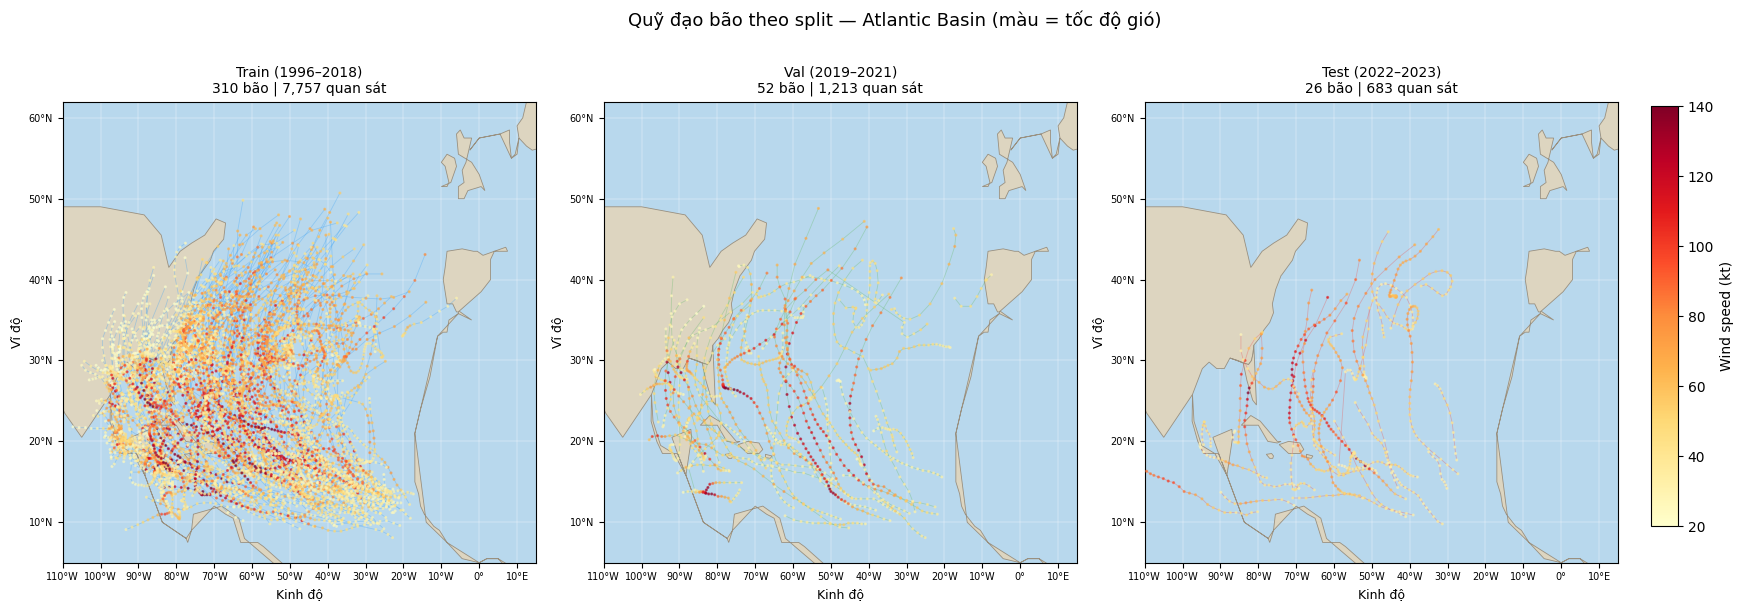

In [6]:
# ── Bản đồ địa lý: quỹ đạo Train / Val / Test ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

split_cfg = [
    ('Train', df_train, '#42a5f5', f'Train ({TRAIN_YEARS[0]}–{TRAIN_YEARS[1]})'),
    ('Val',   df_val,   '#66bb6a', f'Val ({VAL_YEARS[0]}–{VAL_YEARS[1]})'),
    ('Test',  df_test,  '#ef5350', f'Test ({TEST_YEARS[0]}–{TEST_YEARS[1]})'),
]

for ax, (name, d, clr, title) in zip(axes, split_cfg):
    draw_atlantic_basemap(ax, extent=(-110, 15, 5, 62))

    if len(d) == 0:
        ax.set_title(f'{title}\n(không có dữ liệu)', fontsize=10)
        continue

    # Vẽ từng quỹ đạo theo cấp độ màu
    for sid, grp in d.groupby('storm_id'):
        g = grp.sort_values('timestamp')
        ax.plot(g['lon'], g['lat'], '-', color=clr, linewidth=0.6,
                alpha=0.35, zorder=3)

    # Scatter điểm theo cường độ
    sc = ax.scatter(
        d['lon'], d['lat'],
        c=d['wind_kt'].fillna(0), cmap='YlOrRd',
        s=1.5, vmin=20, vmax=140,
        alpha=0.6, zorder=4
    )

    n_storms = d['storm_id'].nunique()
    ax.set_title(
        f'{title}\n{n_storms} bão | {len(d):,} quan sát',
        fontsize=10, pad=6
    )

# Colorbar chung
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=20, vmax=140))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Wind speed (kt)')

fig.suptitle(
    'Quỹ đạo bão theo split — Atlantic Basin (màu = tốc độ gió)',
    fontsize=13, y=1.01
)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(PLOT_DIR/'10_tracks_by_split_map.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Chuẩn hóa Features (StandardScaler)

In [7]:
# Quy tắc: CHỈ fit trên train, transform val & test
scaler = StandardScaler()
scaler.fit(df_train[INPUT_FEATURES].fillna(0))

def apply_scaler(d, feats, sc):
    out = d.copy()
    out[feats] = sc.transform(d[feats].fillna(0))
    return out

df_train_sc = apply_scaler(df_train, INPUT_FEATURES, scaler)
df_val_sc   = apply_scaler(df_val,   INPUT_FEATURES, scaler)
df_test_sc  = apply_scaler(df_test,  INPUT_FEATURES, scaler)

with open(SPLIT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler lưu → data/splits/scaler.pkl')

# Kiểm tra: train scaled mean ≈ 0, std ≈ 1
chk = df_train_sc[INPUT_FEATURES[:5]].describe().loc[['mean','std']].round(4)
print('Kiểm tra (5 features đầu):')
display(chk)


Scaler lưu → data/splits/scaler.pkl
Kiểm tra (5 features đầu):


,lat,lon,delta_lat,delta_lon,speed_kmh
mean,0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0001,1.0001,1.0001,1.0001,1.0001


---
## 5. Tạo Sliding Window

```
Bão với N quan sát (mỗi bước 6h):

  ┌──────────── WINDOW = 8 bước (48h) ────────────┐
  │ t-7  t-6  t-5  t-4  t-3  t-2  t-1   t0        │→ dự đoán tại t+1,+2,+4,+8,+12
  └───────────────────────────────────────────────┘       ↕        ↕    ↕    ↕    ↕
                                                         +6h      +12h +24h +48h +72h
  Slide 1 bước:
  ┌──────────── WINDOW = 8 bước (48h) ────────────┐
  │ t-6  t-5  t-4  t-3  t-2  t-1  t0   t+1        │→ dự đoán tại t+2,+3,+5,+9,+13
  └───────────────────────────────────────────────┘
```
**Shape output:**
- `X`           : `[N_samples, 8, n_features]`
- `y_track`     : `[N_samples, 5, 2]`  — (Δlat, Δlon) × 5 horizons
- `y_intensity` : `[N_samples, 5, 3]`  — (wind_kt, pressure_mb, intensity_class) × 5 horizons


In [8]:
def build_windows(
    df_sc: pd.DataFrame,
    input_features: list,
    target_track: list,
    target_intensity: list,
    target_class: list,
    window_size: int,
    horizons_steps: list,
    verbose: bool = True,
) -> dict:
    """
    Tạo sliding window qua tất cả cơn bão.

    Returns
    -------
    dict:
      X           : [N, W, F]  float32
      y_track     : [N, H, 2]  float32  — Δlat, Δlon
      y_intensity : [N, H, 3]  float32  — wind, pres, class
      meta        : DataFrame  — storm_id, timestamp_end, year, lat, lon
    """
    max_step  = max(horizons_steps)
    n_feat    = len(input_features)
    n_hor     = len(horizons_steps)
    tgt_int   = [t for t in target_intensity + target_class if t in df_sc.columns]
    n_int     = len(tgt_int)

    X_list, y_trk_list, y_int_list, meta_list = [], [], [], []

    for storm_id, grp in df_sc.groupby('storm_id', sort=False):
        grp = grp.sort_values('timestamp').reset_index(drop=True)
        n   = len(grp)
        if n < window_size + max_step:
            continue

        feat_arr = grp[input_features].values.astype(np.float32)    # [N, F]
        trk_arr  = grp[target_track].values.astype(np.float32)      # [N, 2]
        int_arr  = grp[tgt_int].values.astype(np.float32)           # [N, n_int]

        for start in range(0, n - window_size - max_step + 1):
            end = start + window_size   # index của bước hiện tại (exclusive)

            X_w = feat_arr[start:end]                              # [W, F]

            # y tại mỗi horizon: end + h - 1  (vì horizon=1 tức là bước ngay sau)
            y_t = np.array(
                [trk_arr[end + h - 1] for h in horizons_steps],
                dtype=np.float32
            )   # [H, 2]
            y_i = np.array(
                [int_arr[end + h - 1] for h in horizons_steps],
                dtype=np.float32
            )   # [H, n_int]

            X_list.append(X_w)
            y_trk_list.append(y_t)
            y_int_list.append(y_i)
            meta_list.append({
                'storm_id'    : storm_id,
                'timestamp_end': grp['timestamp'].iloc[end - 1],
                'year'         : int(grp['year'].iloc[end - 1]) if 'year' in grp else 0,
                'lat_now'      : float(grp['lat'].iloc[end - 1]),
                'lon_now'      : float(grp['lon'].iloc[end - 1]),
                'wind_now'     : float(grp['wind_kt'].iloc[end - 1]) if 'wind_kt' in grp else 0,
            })

    if not X_list:
        print('  ⚠ Không tạo được sample nào!')
        return {}

    out = {
        'X'          : np.stack(X_list,      axis=0),   # [N, W, F]
        'y_track'    : np.stack(y_trk_list,   axis=0),   # [N, H, 2]
        'y_intensity': np.stack(y_int_list,   axis=0),   # [N, H, n_int]
        'meta'       : pd.DataFrame(meta_list),
    }

    if verbose:
        N = len(X_list)
        print(f'  X            : {out["X"].shape}   (samples × window × features)')
        print(f'  y_track      : {out["y_track"].shape}   (samples × horizons × 2)')
        print(f'  y_intensity  : {out["y_intensity"].shape}   (samples × horizons × {n_int})')
        print(f'  Bão covered  : {out["meta"]["storm_id"].nunique()}')
    return out


common = dict(
    input_features   = INPUT_FEATURES,
    target_track     = TARGET_TRACK,
    target_intensity = TARGET_INTENSITY,
    target_class     = TARGET_CLASS,
    window_size      = WINDOW_SIZE,
    horizons_steps   = HORIZONS_STEPS,
)

print('=== TRAIN ===')
train_data = build_windows(df_train_sc, **common)
print('\n=== VAL ===')
val_data   = build_windows(df_val_sc,   **common)
print('\n=== TEST ===')
test_data  = build_windows(df_test_sc,  **common)


=== TRAIN ===
  X            : (2790, 8, 27)   (samples × window × features)
  y_track      : (2790, 5, 2)   (samples × horizons × 2)
  y_intensity  : (2790, 5, 3)   (samples × horizons × 3)
  Bão covered  : 150

=== VAL ===
  X            : (344, 8, 27)   (samples × window × features)
  y_track      : (344, 5, 2)   (samples × horizons × 2)
  y_intensity  : (344, 5, 3)   (samples × horizons × 3)
  Bão covered  : 31

=== TEST ===
  X            : (232, 8, 27)   (samples × window × features)
  y_track      : (232, 5, 2)   (samples × horizons × 2)
  y_intensity  : (232, 5, 3)   (samples × horizons × 3)
  Bão covered  : 15


---
## 6. Kiểm tra chất lượng windows

In [9]:
print('=== NaN / Inf check ===')
for name, data in [('Train',train_data),('Val',val_data),('Test',test_data)]:
    if not data: continue
    for key in ['X','y_track','y_intensity']:
        n_nan = int(np.isnan(data[key]).sum())
        n_inf = int(np.isinf(data[key]).sum())
        flag  = ' ⚠' if (n_nan+n_inf) > 0 else ' ✓'
        print(f'  {name:5s} [{key:11s}]: NaN={n_nan:,}  Inf={n_inf:,}{flag}')

# Thay NaN/Inf bằng 0
for data in [train_data, val_data, test_data]:
    if not data: continue
    for key in ['X','y_track','y_intensity']:
        data[key] = np.nan_to_num(data[key], nan=0.0, posinf=0.0, neginf=0.0)
print('\nĐã thay NaN/Inf → 0.')


=== NaN / Inf check ===
  Train [X          ]: NaN=0  Inf=0 ✓
  Train [y_track    ]: NaN=0  Inf=0 ✓
  Train [y_intensity]: NaN=0  Inf=0 ✓
  Val   [X          ]: NaN=0  Inf=0 ✓
  Val   [y_track    ]: NaN=0  Inf=0 ✓
  Val   [y_intensity]: NaN=0  Inf=0 ✓
  Test  [X          ]: NaN=0  Inf=0 ✓
  Test  [y_track    ]: NaN=0  Inf=0 ✓
  Test  [y_intensity]: NaN=0  Inf=0 ✓

Đã thay NaN/Inf → 0.


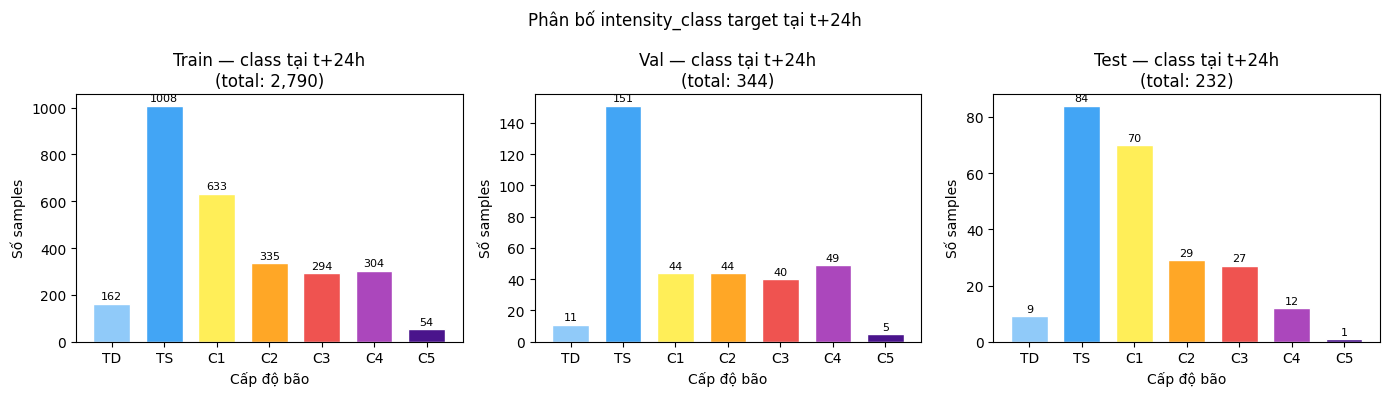


Class imbalance (Train, t+24h):
  TD  :   162 (  5.8%)
  TS  : 1,008 ( 36.1%)
  C1  :   633 ( 22.7%)
  C2  :   335 ( 12.0%)
  C3  :   294 ( 10.5%)
  C4  :   304 ( 10.9%)
  C5  :    54 (  1.9%)
→ Sẽ dùng Focal Loss trong Notebook 4.0 để xử lý imbalance.


In [10]:
# ── Class balance: intensity_class tại t+24h ───────────────────────────────────
# y_intensity shape: [N, H, n_targets]  — cột cuối = intensity_class
H24_IDX = HORIZONS_STEPS.index(4) if 4 in HORIZONS_STEPS else 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
SAFFIR_COLORS = ['#90caf9','#42a5f5','#ffee58','#ffa726','#ef5350','#ab47bc','#4a148c']

for ax, (name, data) in zip(axes, [
    ('Train',train_data),('Val',val_data),('Test',test_data)
]):
    if not data:
        ax.set_title(f'{name} (trống)')
        continue

    cls_col = -1   # intensity_class là cột cuối của y_intensity
    cls     = data['y_intensity'][:, H24_IDX, cls_col]
    cls     = cls[~np.isnan(cls)].astype(int)
    uniq, cnts = np.unique(cls, return_counts=True)
    labels  = [SAFFIR_LABEL.get(u, str(u)) for u in uniq]
    colors  = [SAFFIR_COLORS[u] if u < len(SAFFIR_COLORS) else '#ccc' for u in uniq]

    bars = ax.bar(labels, cnts, color=colors, edgecolor='white', width=0.7)
    ax.set_xlabel('Cấp độ bão'); ax.set_ylabel('Số samples')
    ax.set_title(f'{name} — class tại t+24h\n(total: {len(cls):,})')
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x()+bar.get_width()/2, cnt+cnts.max()*0.01,
                str(cnt), ha='center', va='bottom', fontsize=8)

plt.suptitle('Phân bố intensity_class target tại t+24h', fontsize=12)
plt.tight_layout()
plt.savefig(PLOT_DIR/'11_class_balance_by_split.png', dpi=150, bbox_inches='tight')
plt.show()

# In imbalance ratio
print('\nClass imbalance (Train, t+24h):')
cls_tr = train_data['y_intensity'][:, H24_IDX, -1]
uniq, cnts = np.unique(cls_tr[~np.isnan(cls_tr)].astype(int), return_counts=True)
for u, c in zip(uniq, cnts):
    pct = c/cnts.sum()*100
    print(f'  {SAFFIR_LABEL.get(u,str(u)):3s} : {c:5,} ({pct:5.1f}%)')
print('→ Sẽ dùng Focal Loss trong Notebook 4.0 để xử lý imbalance.')


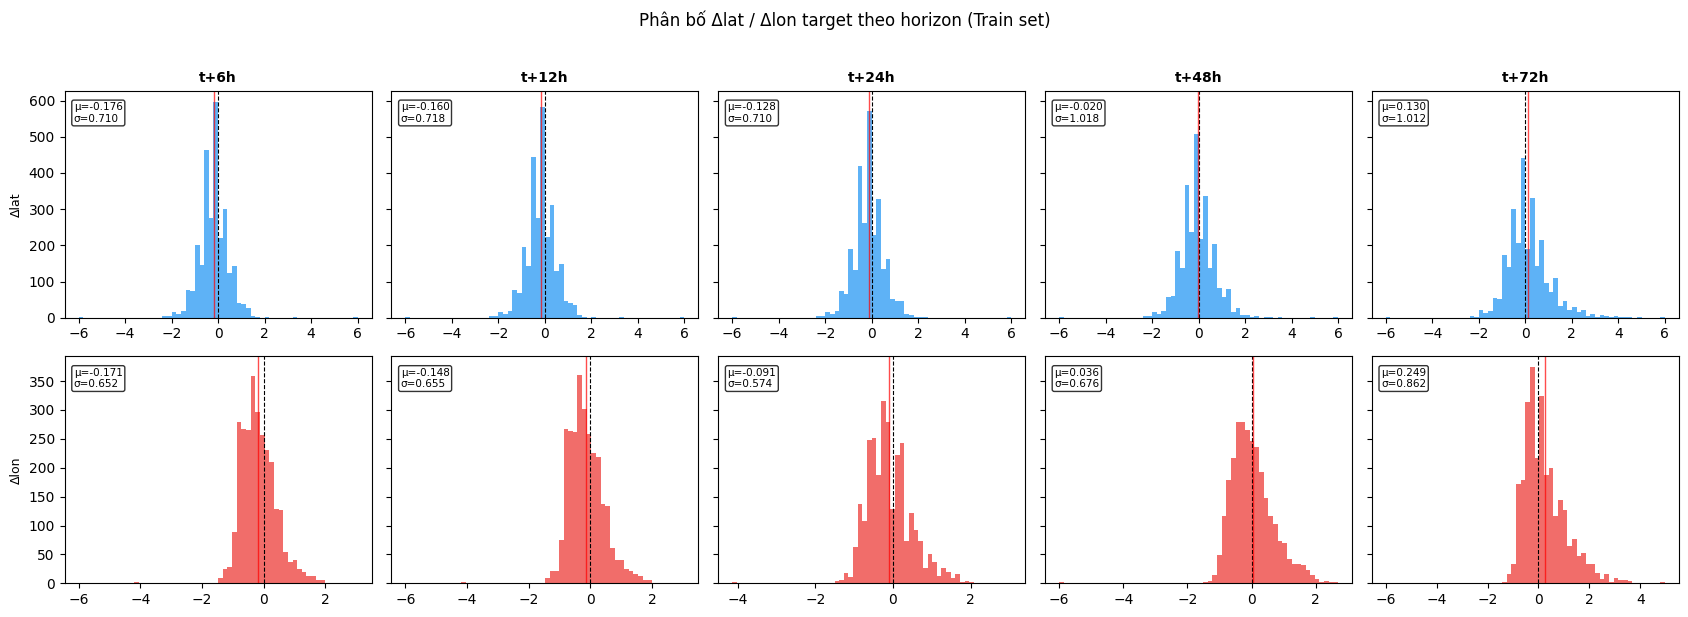

In [11]:
# ── Phân bố Δlat, Δlon theo từng horizon ──────────────────────────────────────
fig, axes = plt.subplots(2, len(HORIZONS_H), figsize=(17, 6), sharey='row')

for col, (h, hs) in enumerate(zip(HORIZONS_H, HORIZONS_STEPS)):
    h_idx = HORIZONS_STEPS.index(hs)
    for row, (tgt_col, tgt_name, clr) in enumerate([
        (0, 'Δlat', '#42a5f5'),
        (1, 'Δlon', '#ef5350'),
    ]):
        ax   = axes[row, col]
        vals = train_data['y_track'][:, h_idx, tgt_col]
        ax.hist(vals.clip(-6, 6), bins=60, color=clr, edgecolor='none', alpha=0.85)
        ax.axvline(0, color='black', lw=0.8, linestyle='--')
        ax.axvline(vals.mean(), color='red', lw=1, linestyle='-', alpha=0.7)
        if row == 0:
            ax.set_title(f't+{h}h', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(tgt_name, fontsize=9)
        ax.text(0.03, 0.95,
                f'μ={vals.mean():.3f}\nσ={vals.std():.3f}',
                transform=ax.transAxes, va='top', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

plt.suptitle('Phân bố Δlat / Δlon target theo horizon (Train set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR/'12_target_track_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()


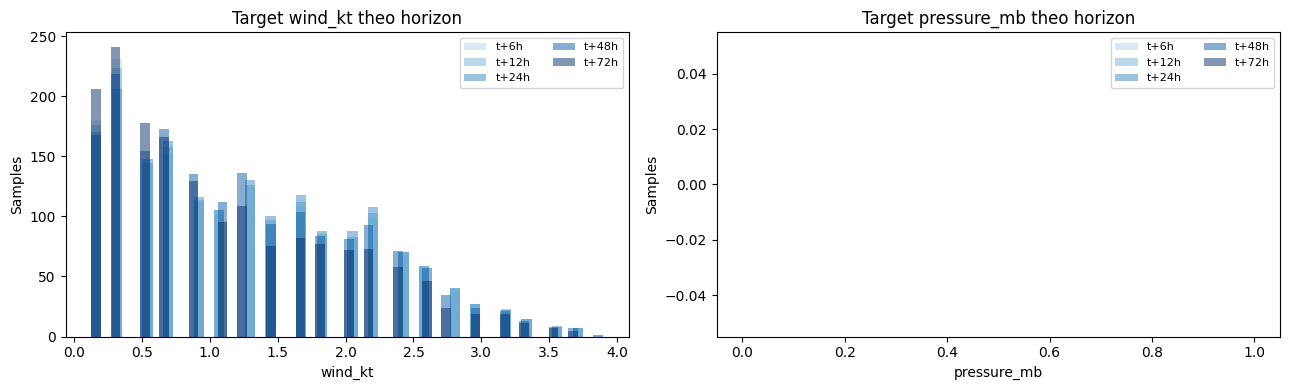

In [12]:
# ── Wind & Pressure target theo horizon ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
blues = plt.cm.Blues(np.linspace(0.3, 1.0, len(HORIZONS_H)))

for h_idx, (h, clr) in enumerate(zip(HORIZONS_H, blues)):
    w_vals = train_data['y_intensity'][:, h_idx, 0]
    p_vals = train_data['y_intensity'][:, h_idx, 1]
    axes[0].hist(w_vals[(w_vals > 0)], bins=50, alpha=0.5, color=clr, label=f't+{h}h')
    axes[1].hist(p_vals[(p_vals > 850)], bins=50, alpha=0.5, color=clr, label=f't+{h}h')

axes[0].set_xlabel('wind_kt');   axes[0].set_ylabel('Samples')
axes[0].set_title('Target wind_kt theo horizon')
axes[0].legend(fontsize=8, ncol=2)
axes[1].set_xlabel('pressure_mb'); axes[1].set_ylabel('Samples')
axes[1].set_title('Target pressure_mb theo horizon')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(PLOT_DIR/'13_target_intensity_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# ── Inspect 1 sample cụ thể ────────────────────────────────────────────────────
idx = 0
print(f'=== Sample #{idx} (Train) ===')
m   = train_data['meta'].iloc[idx]
print(f'Storm     : {m["storm_id"]}')
print(f'Timestamp : {m["timestamp_end"]}')
print(f'Vị trí    : lat={m["lat_now"]:.2f}°N  lon={m["lon_now"]:.2f}°E')
print(f'Gió hiện tại: {m["wind_now"]:.0f} kt')
print(f'X shape   : {train_data["X"][idx].shape}  [window × features]')
print()
print('Y — Dự đoán đường đi (Δlat, Δlon):')
print(f'  {"Horizon":>8s}  {"Δlat (°)":>10s}  {"Δlon (°)":>10s}  {"Khoảng cách ≈ km"}')
for h, (dlat, dlon) in zip(HORIZONS_H, train_data['y_track'][idx]):
    dist_km = np.sqrt((dlat*111)**2 + (dlon*111*np.cos(np.radians(m['lat_now'])))**2)
    print(f'  t+{h:3d}h  : {dlat:+10.4f}  {dlon:+10.4f}  ≈ {dist_km:.1f} km')
print()
print('Y — Dự đoán cường độ (wind, pres, class):')
for h, vals in zip(HORIZONS_H, train_data['y_intensity'][idx]):
    cls_lbl = SAFFIR_LABEL.get(int(vals[2]), '?')
    print(f'  t+{h:3d}h  : wind={vals[0]:.0f}kt  pres={vals[1]:.0f}mb  class={cls_lbl}')


=== Sample #0 (Train) ===
Storm     : AL011998
Timestamp : 1998-07-29 12:00:00+00:00
Vị trí    : lat=-1.32°N  lon=1.19°E
Gió hiện tại: -1 kt
X shape   : (8, 27)  [window × features]

Y — Dự đoán đường đi (Δlat, Δlon):
   Horizon    Δlat (°)    Δlon (°)  Khoảng cách ≈ km
  t+  6h  :    -0.4355     -0.7247  ≈ 93.8 km
  t+ 12h  :    -0.2986     -0.7247  ≈ 87.0 km
  t+ 24h  :    -0.2986     -0.5823  ≈ 72.6 km
  t+ 48h  :    -0.5724     -0.5823  ≈ 90.6 km
  t+ 72h  :    +0.1120     -0.6535  ≈ 73.6 km

Y — Dự đoán cường độ (wind, pres, class):
  t+  6h  : wind=-1kt  pres=1mb  class=TS
  t+ 12h  : wind=-1kt  pres=1mb  class=TS
  t+ 24h  : wind=-1kt  pres=1mb  class=TS
  t+ 48h  : wind=-0kt  pres=1mb  class=TS
  t+ 72h  : wind=-1kt  pres=1mb  class=TS


---
## 7. Bản đồ chi tiết: quỹ đạo theo cường độ (Test set)

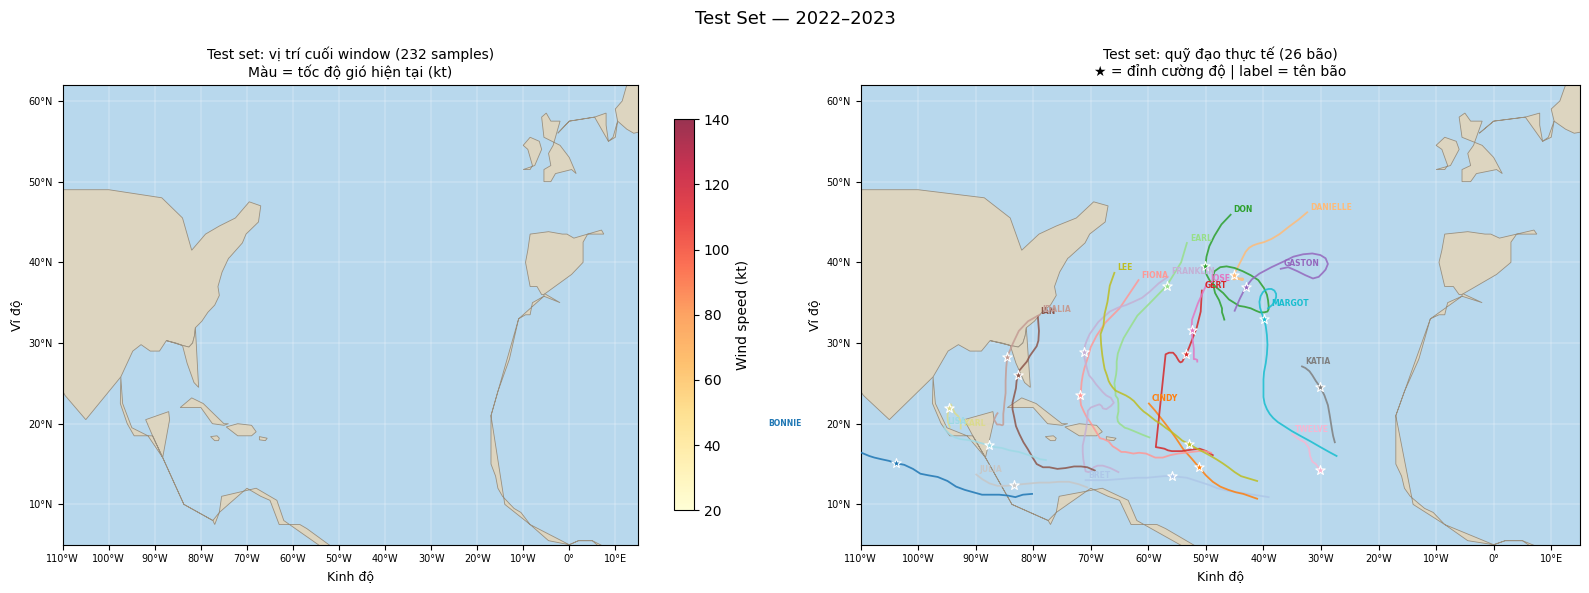

In [14]:
# ── Bản đồ test set: scatter vị trí hiện tại + arrow hướng di chuyển ───────────
if len(test_data.get('meta', [])) > 0:
    meta_test = test_data['meta'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Map 1: vị trí từng window, màu theo wind speed ---
    ax = axes[0]
    draw_atlantic_basemap(ax)
    sc = ax.scatter(
        meta_test['lon_now'], meta_test['lat_now'],
        c=meta_test['wind_now'], cmap='YlOrRd',
        s=8, vmin=20, vmax=140, alpha=0.8, zorder=5
    )
    plt.colorbar(sc, ax=ax, label='Wind speed (kt)', shrink=0.85)
    ax.set_title(
        f'Test set: vị trí cuối window ({len(meta_test):,} samples)\n'
        f'Màu = tốc độ gió hiện tại (kt)',
        fontsize=10
    )

    # --- Map 2: quỹ đạo thực tế của từng bão trong test set ---
    ax2 = axes[1]
    draw_atlantic_basemap(ax2)
    test_storm_ids = df_test['storm_id'].unique()
    cmap_storms = plt.cm.tab20
    for i, sid in enumerate(test_storm_ids[:20]):   # tối đa 20 bão
        sub = df_test[df_test['storm_id']==sid].sort_values('timestamp')
        clr = cmap_storms(i/20)
        ax2.plot(sub['lon'], sub['lat'], '-', color=clr, lw=1.3, alpha=0.85, zorder=3)
        # Điểm peak intensity
        pk = sub.loc[sub['wind_kt'].idxmax()]
        ax2.scatter(pk['lon'], pk['lat'], s=50, color=clr,
                    edgecolors='white', lw=0.8, zorder=6, marker='*')
        # Tên bão
        last = sub.iloc[-1]
        ax2.text(last['lon']+0.5, last['lat']+0.3,
                 sub['storm_name'].iloc[0] if 'storm_name' in sub else sid,
                 fontsize=5.5, color=clr, zorder=7, fontweight='bold')

    ax2.set_title(
        f'Test set: quỹ đạo thực tế ({len(test_storm_ids)} bão)\n'
        f'★ = đỉnh cường độ | label = tên bão',
        fontsize=10
    )

    plt.suptitle(f'Test Set — {TEST_YEARS[0]}–{TEST_YEARS[1]}', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOT_DIR/'14_test_set_map_detail.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Test set trống — bỏ qua bản đồ.')


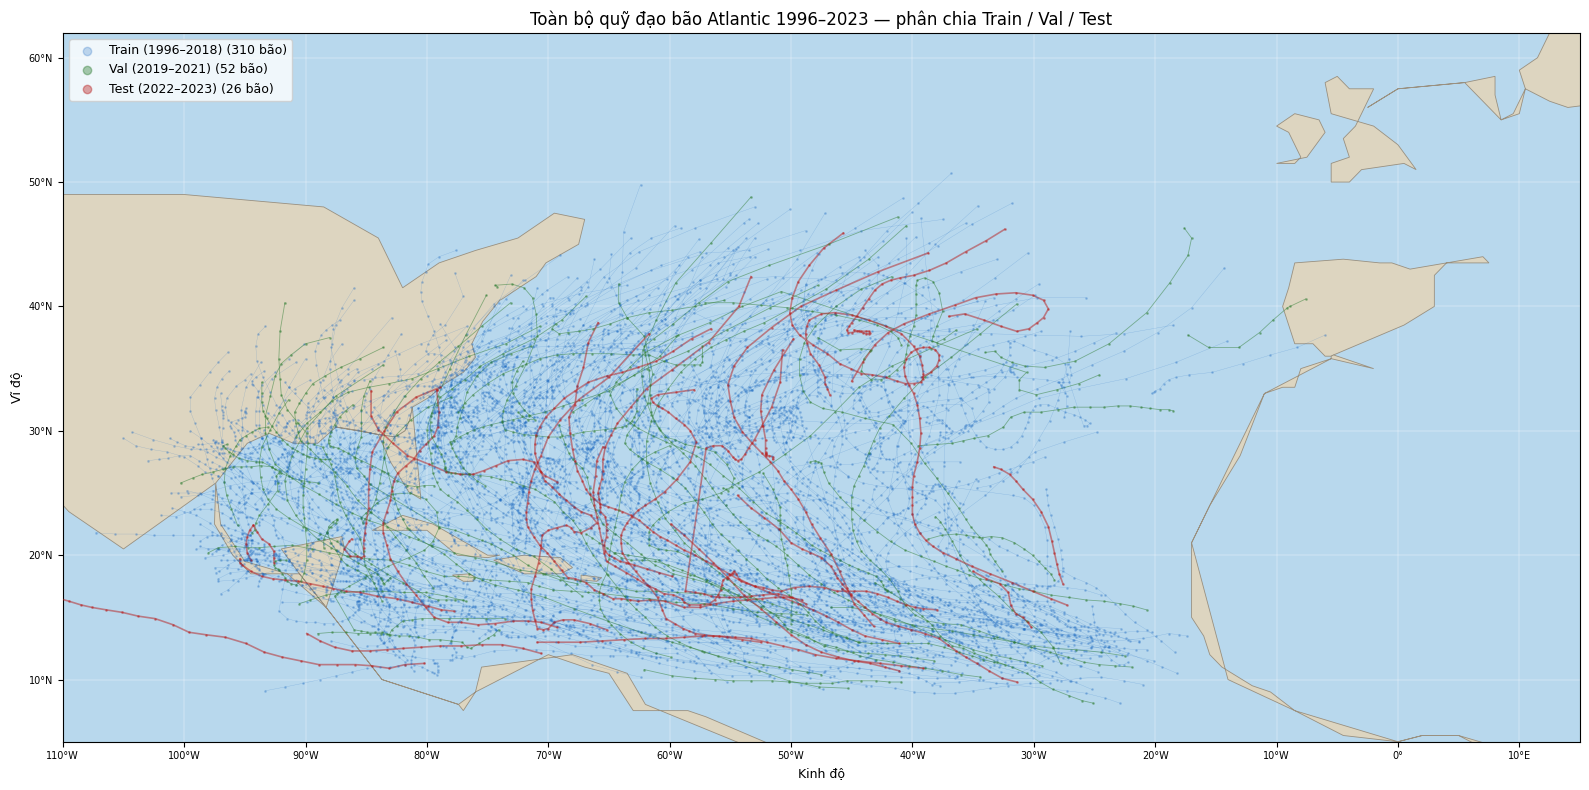

In [15]:
# ── Bản đồ tổng: tất cả bão, màu theo split ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
draw_atlantic_basemap(ax, extent=(-110, 15, 5, 62))

split_styles = [
    (df_train, '#1565c0', 0.25, 0.6, 'Train (1996–2018)'),
    (df_val,   '#2e7d32', 0.6,  1.0, 'Val (2019–2021)'),
    (df_test,  '#b71c1c', 1.2,  1.0, 'Test (2022–2023)'),
]
for d, clr, lw, alpha, label in split_styles:
    for sid, grp in d.groupby('storm_id'):
        g = grp.sort_values('timestamp')
        ax.plot(g['lon'], g['lat'], '-', color=clr, lw=lw,
                alpha=alpha*0.5, zorder=3)
    # Scatter điểm theo wind
    ax.scatter(d['lon'], d['lat'], s=1, color=clr,
               alpha=alpha*0.4, zorder=4, label=f'{label} ({d["storm_id"].nunique()} bão)')

ax.legend(fontsize=9, loc='upper left', markerscale=6)
ax.set_title(
    'Toàn bộ quỹ đạo bão Atlantic 1996–2023 — phân chia Train / Val / Test',
    fontsize=12
)
plt.tight_layout()
plt.savefig(PLOT_DIR/'15_all_tracks_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Tổng kết & Lưu

In [16]:
rows = []
for name, data, d_raw in [
    ('Train', train_data, df_train),
    ('Val',   val_data,   df_val),
    ('Test',  test_data,  df_test),
]:
    N = len(data['X']) if data else 0
    rows.append({
        'Split'         : name,
        'Năm'           : f'{d_raw["year"].min()}–{d_raw["year"].max()}' if len(d_raw) else '-',
        'Bão'           : d_raw['storm_id'].nunique(),
        'Quan sát 6h'   : f'{len(d_raw):,}',
        'Windows'       : f'{N:,}',
        'X shape'       : str(data['X'].shape) if data else '-',
    })

print('\n=== TỔNG KẾT WINDOWS ===')
display(pd.DataFrame(rows))



=== TỔNG KẾT WINDOWS ===


,Split,Năm,Bão,Quan sát 6h,Windows,X shape
0,Train,1996–2018,310,"7,757","2,790","(2790, 8, 27)"
1,Val,2019–2021,52,"1,213",344,"(344, 8, 27)"
2,Test,2022–2023,26,683,232,"(232, 8, 27)"


In [17]:
# ── Lưu tất cả splits ──────────────────────────────────────────────────────────
for name, data in [('train',train_data),('val',val_data),('test',test_data)]:
    if not data: continue
    np.save(SPLIT_DIR / f'{name}_X.npy',           data['X'])
    np.save(SPLIT_DIR / f'{name}_y_track.npy',     data['y_track'])
    np.save(SPLIT_DIR / f'{name}_y_intensity.npy', data['y_intensity'])
    data['meta'].to_parquet(SPLIT_DIR / f'{name}_meta.parquet', index=False)

# Lưu split config
split_cfg = {
    'window_size'     : WINDOW_SIZE,
    'horizons_h'      : HORIZONS_H,
    'horizons_steps'  : HORIZONS_STEPS,
    'step_hours'      : STEP_HOURS,
    'train_years'     : list(TRAIN_YEARS),
    'val_years'       : list(VAL_YEARS),
    'test_years'      : list(TEST_YEARS),
    'input_features'  : INPUT_FEATURES,
    'target_track'    : TARGET_TRACK,
    'target_intensity': TARGET_INTENSITY,
    'target_class'    : TARGET_CLASS,
    'n_features'      : len(INPUT_FEATURES),
    'n_samples'       : {
        'train': int(len(train_data['X'])),
        'val'  : int(len(val_data['X'])),
        'test' : int(len(test_data['X'])),
    },
    'shapes': {
        'X'          : list(train_data['X'].shape),
        'y_track'    : list(train_data['y_track'].shape),
        'y_intensity': list(train_data['y_intensity'].shape),
    }
}
(SPLIT_DIR / 'split_config.json').write_text(json.dumps(split_cfg, indent=2))

print('Files đã lưu → data/splits/')
for f in sorted(SPLIT_DIR.iterdir()):
    print(f'  {f.name:<38}  {f.stat().st_size/1e3:7.1f} KB')


Files đã lưu → data/splits/
  scaler.pkl                                  1.5 KB
  split_config.json                           1.3 KB
  test_meta.parquet                           9.2 KB
  test_X.npy                                200.6 KB
  test_y_intensity.npy                       14.0 KB
  test_y_track.npy                            9.4 KB
  train_meta.parquet                         43.4 KB
  train_X.npy                              2410.7 KB
  train_y_intensity.npy                     167.5 KB
  train_y_track.npy                         111.7 KB
  val_meta.parquet                           11.7 KB
  val_X.npy                                 297.3 KB
  val_y_intensity.npy                        20.8 KB
  val_y_track.npy                            13.9 KB


In [18]:
print('=' * 65)
print('  TỔNG KẾT NOTEBOOK 2.0')
print('=' * 65)
print(f'  Window size      : {WINDOW_SIZE} bước = {WINDOW_SIZE*STEP_HOURS}h lịch sử')
print(f'  Horizons         : {HORIZONS_H}h')
print(f'  Train windows    : {len(train_data["X"]):,}')
print(f'  Val windows      : {len(val_data["X"]):,}')
print(f'  Test windows     : {len(test_data["X"]):,}')
print(f'  X shape          : {train_data["X"].shape}')
print(f'  y_track shape    : {train_data["y_track"].shape}')
print(f'  y_intensity shape: {train_data["y_intensity"].shape}')
print(f'  Scaler           : data/splits/scaler.pkl')
print('=' * 65)
print('  → Notebook 3.0: Augmentation & PyTorch DataLoader (GPU)')
print('  → Notebook 4.0: Training Bi-LSTM + Transformer trên GPU')


  TỔNG KẾT NOTEBOOK 2.0
  Window size      : 8 bước = 48h lịch sử
  Horizons         : [6, 12, 24, 48, 72]h
  Train windows    : 2,790
  Val windows      : 344
  Test windows     : 232
  X shape          : (2790, 8, 27)
  y_track shape    : (2790, 5, 2)
  y_intensity shape: (2790, 5, 3)
  Scaler           : data/splits/scaler.pkl
  → Notebook 3.0: Augmentation & PyTorch DataLoader (GPU)
  → Notebook 4.0: Training Bi-LSTM + Transformer trên GPU
